In [15]:
#random forest
#  Part 1: Data Loading and Preparation (Corrected) 
import pandas as pd
from sklearn.model_selection import train_test_split   # For splitting dataset later
from sklearn.preprocessing import StandardScaler        # For scaling features later
import warnings
warnings.filterwarnings('ignore')

#  Load dataset 
try:
    df = pd.read_csv(r"C:\Users\Admin\Downloads\final_preprocessed_dataset.csv")
    print(f"Dataset loaded. Original shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: 'final_preprocessed_dataset.csv' file not found.")
    exit()

# --- Clean dataset ---
# Remove rows with missing target values

original_count = len(df)
df.dropna(subset=['Depression'], inplace=True)
print(f"Removed {original_count - len(df)} rows with missing 'Depression' values.")

#Split data features(x) and target(y) 

X = df.drop('Depression', axis=1)
y = df['Depression']
print("Data loading and preparation complete.")# Confirm data ready

Dataset loaded. Original shape: (22301, 30)
Removed 0 rows with missing 'Depression' values.
Data loading and preparation complete.


In [16]:
#  Part 2: Data Splitting and Feature Scaling
# Split data into training and testing sets
# Split data into training (70%) and testing (30%) sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features so all have similar range

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled.")# Confirm

Data successfully split and scaled.


In [17]:
# Part 3:"Varieties"# Import Random Forest model 

from sklearn.ensemble import RandomForestClassifier

# Create 3 different Random Forest models with different parameters

rf_var1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
# 100 trees, max depth 5
rf_var2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
# 100 trees, max depth 10
rf_var3 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
# 200 trees, max depth 10

# Store models and their names for easy reference
models = [rf_var1, rf_var2, rf_var3]
model_names = ['RF (100 Trees, Depth=5)', 'RF (100 Trees, Depth=10)', 'RF (200 Trees, Depth=10)']

print("Defined 3 varieties for Random Forest.")

Defined 3 varieties for Random Forest.


In [18]:
# Part 4: Train and Evaluate All 3 Varieties 
from sklearn.metrics import classification_report, confusion_matrix, f1_score  # Evaluation tools
import time # To  training time

results = {} # to store weighted F1-scores

# Loop  all models and their names
for model, name in zip(models, model_names):
    print(f"--- Training and Evaluating: {name} ---")
    print("Training... (This may take a moment)...")
    start_time = time.time()

   # 1. Train the model on training data
    model.fit(X_train_scaled, y_train)

    end_time = time.time()
    print(f"Training finished in {end_time - start_time:.2f} seconds.")

      # 2. Make predictions on test data
    y_pred = model.predict(X_test_scaled)

    # 3. Evaluate with classification report (Precision, Recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Depression', 'Depression']))

    # 4. Evaluate with confusion matrix (True vs Predicted)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # 5. Calculate weighted F1-score and store for comparison
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = f1
    print(f"Weighted F1-Score: {f1:.4f}")
    print("---------------------------------------------------\n")
    
#F1 score tells how accurate your model is,
#by checking how well it finds the correct answers (recall)
#and how few mistakes it makes (precision).

--- Training and Evaluating: RF (100 Trees, Depth=5) ---
Training... (This may take a moment)...
Training finished in 0.63 seconds.

Classification Report:
               precision    recall  f1-score   support

No Depression       0.80      0.74      0.77      2751
   Depression       0.83      0.87      0.85      3940

     accuracy                           0.82      6691
    macro avg       0.81      0.80      0.81      6691
 weighted avg       0.81      0.82      0.81      6691

Confusion Matrix:
[[2024  727]
 [ 509 3431]]
Weighted F1-Score: 0.8140
---------------------------------------------------

--- Training and Evaluating: RF (100 Trees, Depth=10) ---
Training... (This may take a moment)...
Training finished in 0.98 seconds.

Classification Report:
               precision    recall  f1-score   support

No Depression       0.82      0.77      0.79      2751
   Depression       0.85      0.88      0.86      3940

     accuracy                           0.84      6691
    macr

--- Comparison of Member 5's Varieties ---
RF (100 Trees, Depth=5): 0.8140
RF (100 Trees, Depth=10): 0.8360
RF (200 Trees, Depth=10): 0.8362

Conclusion: The best variety for Random Forest is 'RF (200 Trees, Depth=10)'.

✅ Individual comparison chart saved to 'member_5_varieties_chart.png'
✅ Text summary saved to 'member_5_results.txt'


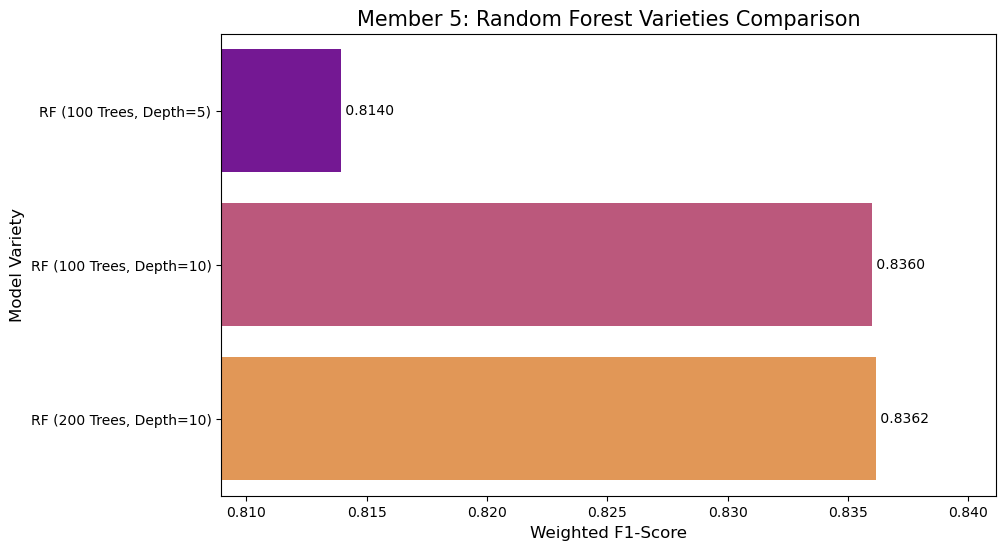

In [19]:
#  Part 5: Final Conclusion, Save Text & Create Chart (Member 5) 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Find the best Random Forest variety based on F1-score
best_model_name = max(results, key=results.get)
best_f1_score = results[best_model_name]

# Print all F1-scores for comparison
print(f"--- Comparison of Member 5's Varieties ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

print(f"\nConclusion: The best variety for Random Forest is '{best_model_name}'.")

#Individual chart output

# 2. Prepare data for chart
df_member5 = pd.DataFrame(list(results.items()), columns=['Variety', 'F1-Score'])

# 3. Create bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Variety', data=df_member5, palette='plasma')
plt.title('Member 5: Random Forest Varieties Comparison', fontsize=15)
plt.xlabel('Weighted F1-Score', fontsize=12)
plt.ylabel('Model Variety', fontsize=12)
plt.xlim(min(df_member5['F1-Score']) - 0.005, max(df_member5['F1-Score']) + 0.005)

# Add F1-score text on each bar
for index, value in enumerate(df_member5['F1-Score']):
    plt.text(value, index, f' {value:.4f}', va='center')

# 4. Save chart as an image
chart_filename = "member_5_varieties_chart.png"
plt.savefig(chart_filename)
print(f"\n✅ Individual comparison chart saved to '{chart_filename}'")

# 5. Save text summary of results

file_content = f"""
--- MEMBER 5: FINAL OPTIMUM RESULT ---
Model: Random Forest
Optimum Variety: {best_model_name}
Final Weighted F1-Score for Group Comparison: {best_f1_score:.4f}
--- Details of All Varieties Tested ---
"""
for name, score in results.items():
    file_content += f"{name}: {score:.4f}\n"

text_filename = "member_5_results.txt"
with open(text_filename, 'w') as f:
    f.write(file_content)

print(f"✅ Text summary saved to '{text_filename}'")